# 01. 데이터 로드 및 전처리
- 23~25년 실거래가 데이터 로드 및 합치기
- 불필요한 컬럼 제거 및 기본 전처리
- 이상치 및 결측치 처리
- 위도/경도 변환 (카카오 지오코딩 API)
- 전처리 완료 데이터 저장

## 0. 라이브러리 로드

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import sys
import os
import time
from tqdm import tqdm

# 한글 폰트 설정 (OS별 자동 감지)
import platform
if platform.system() == 'Darwin':       # Mac
    matplotlib.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':    # Windows
    matplotlib.rcParams['font.family'] = 'Malgun Gothic'
else:                                    # Linux / Colab
    matplotlib.rcParams['font.family'] = 'NanumGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# utils.py 경로 추가
sys.path.append('../src')
from utils import get_coords_kakao

## 1. 데이터 로드 및 합치기

In [5]:
# 연도별 파일 로드 (상단 15줄 설명 텍스트 제외)
df_2023 = pd.read_csv('../data/raw/실거래가_2023.csv', encoding='cp949', skiprows=15)
df_2024 = pd.read_csv('../data/raw/실거래가_2024.csv', encoding='cp949', skiprows=15)
df_2025 = pd.read_csv('../data/raw/실거래가_2025.csv', encoding='cp949', skiprows=15)

# 합치기
df = pd.concat([df_2023, df_2024, df_2025], ignore_index=True)

print(f'전체 행 수: {len(df)}')
print(f'컬럼 목록: {df.columns.tolist()}')

전체 행 수: 177085
컬럼 목록: ['NO', '시군구', '번지', '본번', '부번', '단지명', '전용면적(㎡)', '계약년월', '계약일', '거래금액(만원)', '동', '층', '매수자', '매도자', '건축년도', '도로명', '해제사유발생일', '거래유형', '중개사소재지', '등기일자']


In [6]:
# 연도별 거래량 확인
df['계약년도'] = df['계약년월'].astype(str).str[:4]
print(df['계약년도'].value_counts().sort_index())

계약년도
2023    35583
2024    57740
2025    83762
Name: count, dtype: int64


## 2. 불필요한 컬럼 제거

In [7]:
# 분석에 불필요한 컬럼 제거
# 제거 근거:
# - NO: 단순 인덱스
# - 번지/본번/부번: 도로명 주소로 대체
# - 동: 결측치 많고 단지명으로 대체 가능
# - 매수자/매도자: 개인정보, 분석 불필요
# - 해제사유발생일: 해제된 거래 처리 후 불필요
# - 거래유형/중개사소재지/등기일자: 가격 예측과 무관

drop_cols = ['NO', '번지', '본번', '부번', '동', '매수자', '매도자',
             '해제사유발생일', '거래유형', '중개사소재지', '등기일자']
df = df.drop(columns=drop_cols)

print(f'잔여 컬럼: {df.columns.tolist()}')

잔여 컬럼: ['시군구', '단지명', '전용면적(㎡)', '계약년월', '계약일', '거래금액(만원)', '층', '건축년도', '도로명', '계약년도']


## 3. 데이터 타입 변환

In [8]:
# 거래금액 쉼표 제거 후 숫자 변환 (이미 숫자형일 가능성 방어)
df['거래금액(만원)'] = (
    df['거래금액(만원)']
    .astype(str)
    .str.replace(',', '', regex=False)
    .astype(int)
)

# 구 이름 추출 (시군구 컬럼에서)
# 예: '서울특별시 송파구 신천동' -> '송파구'
df['구'] = df['시군구'].str.split().str[1]

# 강남권 여부 (강남구, 서초구, 송파구)
gangnam = ['강남구', '서초구', '송파구']
df['강남권'] = df['구'].isin(gangnam).astype(int)

print(df[['시군구', '구', '강남권']].head())
print(f"\n강남권 비율: {df['강남권'].mean():.2%}")

              시군구     구  강남권
0   서울특별시 중랑구 신내동   중랑구    0
1  서울특별시 성북구 하월곡동   성북구    0
2  서울특별시 서대문구 홍은동  서대문구    0
3   서울특별시 노원구 공릉동   노원구    0
4   서울특별시 서초구 잠원동   서초구    1

강남권 비율: 17.50%


## 4. 결측치 확인 및 처리

In [9]:
# 결측치 현황
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({'결측치 수': missing, '결측치 비율(%)': missing_pct}))

          결측치 수  결측치 비율(%)
시군구           0        0.0
단지명           0        0.0
전용면적(㎡)       0        0.0
계약년월          0        0.0
계약일           0        0.0
거래금액(만원)      0        0.0
층             0        0.0
건축년도          0        0.0
도로명           0        0.0
계약년도          0        0.0
구             0        0.0
강남권           0        0.0


In [10]:
# 핵심 컬럼 결측치 제거
# 거래금액, 전용면적, 층, 건축년도는 필수 변수이므로 결측시 제거
essential_cols = ['거래금액(만원)', '전용면적(㎡)', '층', '건축년도']
before = len(df)
df = df.dropna(subset=essential_cols)
after = len(df)
print(f'결측치 제거: {before - after}건 제거 → 잔여 {after}건')

결측치 제거: 0건 제거 → 잔여 177085건


## 5. 이상치 확인 및 처리

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
/tmp/ipykernel_5848/2209343088.py:12: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5848/2209343088.py:12: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5848/2209343088.py:12: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5848/2209343088.py:12: UserWarning: Glyph 50529 (\N{HANGUL SYLLABLE AEG}) missing 

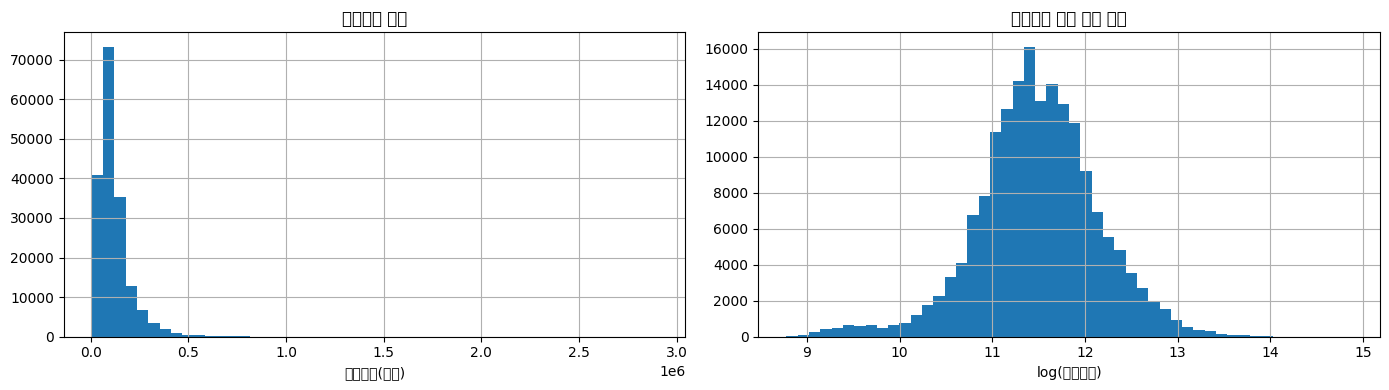

count    1.770850e+05
mean     1.208137e+05
std      9.121225e+04
min      6.500000e+03
25%      6.700000e+04
50%      9.750000e+04
75%      1.470000e+05
max      2.900000e+06
Name: 거래금액(만원), dtype: float64


In [11]:
# 타겟 변수 (거래금액) 분포 확인
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['거래금액(만원)'].hist(bins=50, ax=axes[0])
axes[0].set_title('거래금액 분포')
axes[0].set_xlabel('거래금액(만원)')

np.log1p(df['거래금액(만원)']).hist(bins=50, ax=axes[1])
axes[1].set_title('거래금액 로그 변환 분포')
axes[1].set_xlabel('log(거래금액)')

plt.tight_layout()
plt.show()

print(df['거래금액(만원)'].describe())

In [12]:
# IQR 기준 이상치 비율 확인 (참고용)
# 주의: '층' 컬럼은 1~3층이 정상이지만 IQR 하단 이상치로 잡힐 수 있음.
# 실제 이상치 제거는 다음 셀에서 거래금액 상하위 1%로 수행.
for col in ['거래금액(만원)', '전용면적(㎡)', '층']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_ratio = outlier_count / len(df) * 100
    print(f'{col}: 이상치 {outlier_count}건 ({outlier_ratio:.2f}%) | 범위: {lower:.0f} ~ {upper:.0f}')

거래금액(만원): 이상치 10739건 (6.06%) | 범위: -53000 ~ 267000
전용면적(㎡): 이상치 15282건 (8.63%) | 범위: 22 ~ 123
층: 이상치 2706건 (1.53%) | 범위: -8 ~ 28


In [13]:
# 거래금액 상하위 1% 제거 (극단적 이상치)
# 근거: IQR 방식은 아파트 고가 거래를 과도하게 제거할 수 있어
# 상하위 1% 제거로 극단값만 처리
lower_pct = df['거래금액(만원)'].quantile(0.01)
upper_pct = df['거래금액(만원)'].quantile(0.99)

before = len(df)
df = df[(df['거래금액(만원)'] >= lower_pct) & (df['거래금액(만원)'] <= upper_pct)]
after = len(df)
print(f'이상치 제거: {before - after}건 제거 → 잔여 {after}건')

이상치 제거: 3525건 제거 → 잔여 173560건


## 6. 파생 변수 생성 (기본)

In [14]:
# 노후도: 계약년도 - 건축년도
# 근거: 가이드 4.2절은 building_age = 2024 - 건축연도지만,
#       거래 시점 기준 경과 연수가 가격에 더 직접적 영향을 미친다고 판단해
#       계약년도 기준으로 변경. (3~5년 데이터를 다루므로 차이가 의미 있음)
df['노후도'] = df['계약년도'].astype(int) - df['건축년도']

# 음수 노후도 제거 (데이터 오류 - 분양 전 거래로 추정)
before = len(df)
df = df[df['노후도'] >= 0]
after = len(df)
print(f'음수 노후도 제거: {before - after}건 → 잔여 {after}건')

print(df['노후도'].describe())

음수 노후도 제거: 0건 → 잔여 173560건
count    173560.000000
mean         20.917285
std          11.355056
min           0.000000
25%          12.000000
50%          22.000000
75%          28.000000
max          64.000000
Name: 노후도, dtype: float64


## 7. 위도/경도 변환 (카카오 지오코딩 API)

In [15]:
# 단지별 중복 제거 후 변환 (API 호출 수 최소화)
# 근거: 같은 단지의 여러 거래건마다 API를 호출하면 수만 번 호출 필요
# 단지별로 한 번만 호출 후 병합하면 수백~수천 번으로 감소
unique_apt = df[['단지명', '도로명']].drop_duplicates().reset_index(drop=True)
print(f'고유 단지 수: {len(unique_apt)}')

고유 단지 수: 7070


In [16]:
# 카카오 지오코딩 API로 위도/경도 변환
# 주의: API 호출 간격 0.1초 유지 (rate limit 방지)
# 중간 저장: 500건마다 임시 파일로 저장하여 중단 시 복구 가능

CHECKPOINT_PATH = '../data/processed/geocoding_checkpoint.csv'
os.makedirs('../data/processed', exist_ok=True)

# 기존 체크포인트가 있으면 로드
if os.path.exists(CHECKPOINT_PATH):
    cached = pd.read_csv(CHECKPOINT_PATH)
    print(f'기존 체크포인트 로드: {len(cached)}건')
    unique_apt = unique_apt.merge(
        cached[['단지명', '도로명', '위도', '경도']],
        on=['단지명', '도로명'], how='left'
    )
else:
    unique_apt['위도'] = np.nan
    unique_apt['경도'] = np.nan

# 아직 변환되지 않은 행만 처리
todo_mask = unique_apt['위도'].isnull()
todo_idx = unique_apt[todo_mask].index.tolist()
print(f'변환할 단지: {len(todo_idx)}건 / 전체 {len(unique_apt)}건')

for i, idx in enumerate(tqdm(todo_idx, desc='지오코딩')):
    row = unique_apt.loc[idx]
    address = f"서울특별시 {row['도로명']}"
    lat, lon = get_coords_kakao(address)
    unique_apt.at[idx, '위도'] = lat
    unique_apt.at[idx, '경도'] = lon
    time.sleep(0.1)

    # 500건마다 중간 저장
    if (i + 1) % 500 == 0:
        unique_apt.to_csv(CHECKPOINT_PATH, index=False, encoding='utf-8-sig')

# 최종 저장
unique_apt.to_csv(CHECKPOINT_PATH, index=False, encoding='utf-8-sig')

# 변환 실패 건수 확인
fail_count = unique_apt['위도'].isnull().sum()
print(f'변환 실패: {fail_count}건 / 전체 {len(unique_apt)}건')

기존 체크포인트 로드: 7070건
변환할 단지: 7070건 / 전체 7070건


지오코딩: 100%|██████████| 7070/7070 [20:18<00:00,  5.80it/s]


변환 실패: 19건 / 전체 7070건


In [17]:
# 원본 데이터에 위도/경도 병합
df = df.merge(unique_apt[['단지명', '도로명', '위도', '경도']], 
              on=['단지명', '도로명'], how='left')

# 좌표 변환 실패 행 제거
before = len(df)
df = df.dropna(subset=['위도', '경도'])
after = len(df)
print(f'좌표 없는 행 제거: {before - after}건 → 잔여 {after}건')

좌표 없는 행 제거: 161건 → 잔여 173399건


## 8. 최종 확인 및 저장

In [18]:
# 최종 데이터 현황
print(f'최종 행 수: {len(df)}')
print(f'최종 컬럼: {df.columns.tolist()}')
print(f'\n결측치 현황:')
print(df.isnull().sum())
print(f'\n기본 통계:')
print(df[['거래금액(만원)', '전용면적(㎡)', '층', '노후도']].describe())

최종 행 수: 173399
최종 컬럼: ['시군구', '단지명', '전용면적(㎡)', '계약년월', '계약일', '거래금액(만원)', '층', '건축년도', '도로명', '계약년도', '구', '강남권', '노후도', '위도', '경도']

결측치 현황:
시군구         0
단지명         0
전용면적(㎡)     0
계약년월        0
계약일         0
거래금액(만원)    0
층           0
건축년도        0
도로명         0
계약년도        0
구           0
강남권         0
노후도         0
위도          0
경도          0
dtype: int64

기본 통계:
            거래금액(만원)        전용면적(㎡)              층            노후도
count  173399.000000  173399.000000  173399.000000  173399.000000
mean   116719.369391      75.697362       9.787923      20.905046
std     72852.837209      26.915765       6.465402      11.347167
min     13300.000000      10.780000      -3.000000       0.000000
25%     67500.000000      59.785000       5.000000      12.000000
50%     97500.000000      80.200000       9.000000      21.000000
75%    145000.000000      84.960000      14.000000      28.000000
max    458000.000000     317.360000      68.000000      64.000000


In [19]:
# 전처리 완료 데이터 저장
os.makedirs('../data/processed', exist_ok=True)
df.to_csv('../data/processed/apt_preprocessed.csv', index=False, encoding='utf-8-sig')
print('저장 완료: ../data/processed/apt_preprocessed.csv')

저장 완료: ../data/processed/apt_preprocessed.csv
